In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

In [2]:
# Load cleaned data from EDA
df = pd.read_csv('/home/emeka/projects/ML_Portfolio/Customer-churn-ML/data/cleaned_telco_churn.csv')


# inspect the data
df.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# dataset information
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   seniorcitizen     7043 non-null   int64  
 3   partner           7043 non-null   object 
 4   dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   phoneservice      7043 non-null   object 
 7   multiplelines     7043 non-null   object 
 8   internetservice   7043 non-null   object 
 9   onlinesecurity    7043 non-null   object 
 10  onlinebackup      7043 non-null   object 
 11  deviceprotection  7043 non-null   object 
 12  techsupport       7043 non-null   object 
 13  streamingtv       7043 non-null   object 
 14  streamingmovies   7043 non-null   object 
 15  contract          7043 non-null   object 
 16  paperlessbilling  7043 non-null   object 


In [4]:
# dataset shape
print(df.shape)

(7043, 21)


In [5]:
# Separate features and target variable
X = df.drop(['churn', 'customerid'], axis=1) #features

y = df['churn'] #target variable

print(X.shape)
print(y.shape)


(7043, 19)
(7043,)


In [6]:
# Identify categorical and numerical features
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['gender', 'partner', 'dependents', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod']

Numerical features:
['seniorcitizen', 'tenure', 'monthlycharges', 'totalcharges']


In [7]:
# Move seniorcitizen to categorical features
categorical_features.append('seniorcitizen')
numerical_features.remove('seniorcitizen')

print("Updated Categorical features:")
print(categorical_features)

print("\nUpdated Numerical features:")
print(numerical_features)

Updated Categorical features:
['gender', 'partner', 'dependents', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'seniorcitizen']

Updated Numerical features:
['tenure', 'monthlycharges', 'totalcharges']


In [8]:
# Encode Target Variable
# churn customer : 1, Retained customer : 0
y = y.map({'Yes': 1, 'No': 0})

In [9]:
print(y.head())

0    0
1    0
2    1
3    0
4    1
Name: churn, dtype: int64


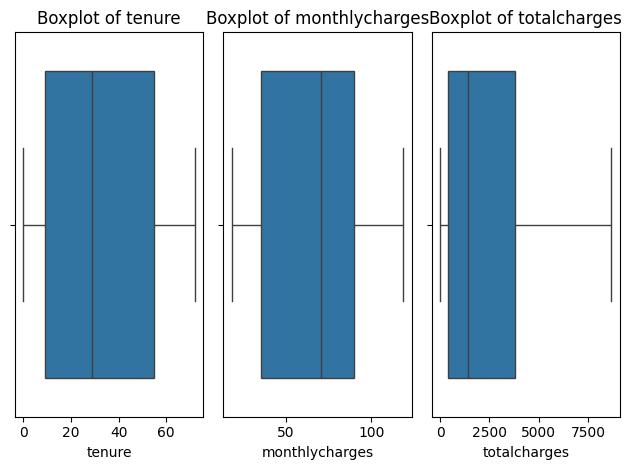

In [10]:
# Box plot for numerical features

for i, col in enumerate(numerical_features):

    plt.subplot(1,3, i+1)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

### Outlier Analysis Insight

The numerical feature distributions were evaluated using boxplots to identify potential outliers and extreme values.

Among the numerical variables, `totalcharges` exhibited the strongest right-skewed distribution due to the accumulation of customer spending over time. However, the distribution did not reveal clear isolated anomaly points that would suggest obvious data errors.

Most of the high-value observations appear to represent legitimate long-term or premium customers rather than invalid records.

For this reason, aggressive outlier removal was not considered appropriate, as removing these observations could distort real customer behavior and reduce the business relevance of the dataset.

Instead, scaling and possible feature transformation techniques may later be considered during model development if required by specific machine learning algorithms.

In [11]:
# Inspecting categorical features
for col in categorical_features:
    print(f"\n {col}:")
    print(df[col].unique())



 gender:
['Female' 'Male']

 partner:
['Yes' 'No']

 dependents:
['No' 'Yes']

 phoneservice:
['No' 'Yes']

 multiplelines:
['No phone service' 'No' 'Yes']

 internetservice:
['DSL' 'Fiber optic' 'No']

 onlinesecurity:
['No' 'Yes' 'No internet service']

 onlinebackup:
['Yes' 'No' 'No internet service']

 deviceprotection:
['No' 'Yes' 'No internet service']

 techsupport:
['No' 'Yes' 'No internet service']

 streamingtv:
['No' 'Yes' 'No internet service']

 streamingmovies:
['No' 'Yes' 'No internet service']

 contract:
['Month-to-month' 'One year' 'Two year']

 paperlessbilling:
['Yes' 'No']

 paymentmethod:
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

 seniorcitizen:
[0 1]


In [12]:
# spliting categorical features into binary and multi-category features
binary_features = [col for col in categorical_features if df[col].nunique() == 2]
multi_category_features = [col for col in categorical_features if df[col].nunique() > 2]
print("Binary features:")
print(binary_features)
print("\nMulti-category features:")
print(multi_category_features)

Binary features:
['gender', 'partner', 'dependents', 'phoneservice', 'paperlessbilling', 'seniorcitizen']

Multi-category features:
['multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paymentmethod']


In [13]:
# create copy before encoding
X_encoded = X.copy()

binary_mappings = {
    'gender': {'Male': 1, 'Female': 0},
    'partner': {'Yes': 1, 'No': 0},
    'dependents': {'Yes': 1, 'No': 0},
    'phoneservice': {'Yes': 1, 'No': 0},
    'paperlessbilling': {'Yes': 1, 'No': 0},
    }

# Apply binary encoding
for col, mapping in binary_mappings.items():
    X_encoded[col] = X_encoded[col].map(mapping)
    
# preview the encoded data
X_encoded.head()

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges
0,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85
1,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50
2,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15
3,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75
4,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65


In [14]:
from sklearn.preprocessing import OneHotEncoder

# One-hot encode multi-category features
multi_category_features = ['multiplelines', 
                           'internetservice', 
                           'onlinesecurity', 
                           'onlinebackup', 
                           'deviceprotection', 
                           'techsupport', 
                           'streamingtv', 
                           'streamingmovies', 
                           'contract', 
                           'paymentmethod']

# initialize the encoder
encoder = OneHotEncoder(sparse_output=False, drop='first')

# fit and transform the multi-category features
encoded_features = encoder.fit_transform(X_encoded[multi_category_features])

# convert the encoded features to a DataFrame
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(multi_category_features), index=X_encoded.index)

# Preview
encoded_df.head()

,multiplelines_No phone service,multiplelines_Yes,internetservice_Fiber optic,internetservice_No,onlinesecurity_No internet service,onlinesecurity_Yes,onlinebackup_No internet service,onlinebackup_Yes,deviceprotection_No internet service,deviceprotection_Yes,techsupport_No internet service,techsupport_Yes,streamingtv_No internet service,streamingtv_Yes,streamingmovies_No internet service,streamingmovies_Yes,contract_One year,contract_Two year,paymentmethod_Credit card (automatic),paymentmethod_Electronic check,paymentmethod_Mailed check
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [15]:
encoded_df.shape

(7043, 21)

In [16]:
# Remove original multi-category features
X_final = X_encoded.drop(columns=multi_category_features)

# Concatenate the encoded features with the original DataFrame
X_final = pd.concat([X_final, encoded_df], axis=1)

# Preview final dataset
X_final.head()

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,paperlessbilling,monthlycharges,totalcharges,multiplelines_No phone service,multiplelines_Yes,internetservice_Fiber optic,internetservice_No,onlinesecurity_No internet service,onlinesecurity_Yes,onlinebackup_No internet service,onlinebackup_Yes,deviceprotection_No internet service,deviceprotection_Yes,techsupport_No internet service,techsupport_Yes,streamingtv_No internet service,streamingtv_Yes,streamingmovies_No internet service,streamingmovies_Yes,contract_One year,contract_Two year,paymentmethod_Credit card (automatic),paymentmethod_Electronic check,paymentmethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1,0,0,0,34,1,0,56.95,1889.50,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,1,0,0,0,2,1,1,53.85,108.15,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1,0,0,0,45,0,0,42.30,1840.75,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0,0,0,0,2,1,1,70.70,151.65,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [17]:
X_final.shape

(7043, 30)

In [18]:
# Check datatype
X_final.dtypes.value_counts()

float64    23
int64       7
Name: count, dtype: int64

In [19]:
from sklearn.model_selection import train_test_split

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, stratify=y, random_state=42)

# Check shapes of the splits
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5634, 30)
X_test shape: (1409, 30)
y_train shape: (5634,)
y_test shape: (1409,)


In [20]:
from sklearn.preprocessing import RobustScaler

# Initialize the scaler
scaler = RobustScaler()

# Scale numerical features in training set
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])

X_test[numerical_features] = scaler.transform(X_test[numerical_features])

X_train.head()

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,paperlessbilling,monthlycharges,totalcharges,multiplelines_No phone service,multiplelines_Yes,internetservice_Fiber optic,internetservice_No,onlinesecurity_No internet service,onlinesecurity_Yes,onlinebackup_No internet service,onlinebackup_Yes,deviceprotection_No internet service,deviceprotection_Yes,techsupport_No internet service,techsupport_Yes,streamingtv_No internet service,streamingtv_Yes,streamingmovies_No internet service,streamingmovies_Yes,contract_One year,contract_Two year,paymentmethod_Credit card (automatic),paymentmethod_Electronic check,paymentmethod_Mailed check
3738,1,0,0,0,0.130435,0,0,-0.391994,0.089350,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3151,1,0,1,1,-0.304348,1,0,0.084656,-0.070896,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4860,1,0,1,1,-0.347826,0,0,-0.551185,-0.234375,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3867,0,0,1,0,-0.065217,1,1,0.055210,0.148790,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
3810,1,0,1,1,-0.608696,1,0,-0.477571,-0.393368,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [21]:
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# check new class distribution
print("Original training shape: {}".format(X_train.shape))
print('SMOTE training shape: {}'.format(X_train_smote.shape))

print('\nOriginal class distribution:\n{}'.format(y_train.value_counts()))
print('\nSMOTE class distribution:\n{}'.format(y_train_smote.value_counts()))



Original training shape: (5634, 30)
SMOTE training shape: (8278, 30)

Original class distribution:
churn
0    4139
1    1495
Name: count, dtype: int64

SMOTE class distribution:
churn
0    4139
1    4139
Name: count, dtype: int64


In [22]:
# Save baseline train/test datasets

X_train.to_csv( '/home/emeka/projects/ML_Portfolio/Customer-churn-ML/data/processed/X_train.csv', index=False)

X_test.to_csv('/home/emeka/projects/ML_Portfolio/Customer-churn-ML/data/processed/X_test.csv', index=False)

y_train.to_csv('/home/emeka/projects/ML_Portfolio/Customer-churn-ML/data/processed/y_train.csv', index=False)

y_test.to_csv('/home/emeka/projects/ML_Portfolio/Customer-churn-ML/data/processed/y_test.csv',index=False)

print("Baseline datasets saved successfully.")

Baseline datasets saved successfully.


In [23]:
# Save SMOTE datasets

X_train_smote.to_csv('/home/emeka/projects/ML_Portfolio/Customer-churn-ML/data/processed/X_train_smote.csv', index=False)

y_train_smote.to_csv('/home/emeka/projects/ML_Portfolio/Customer-churn-ML/data/processed/y_train_smote.csv', index=False)

print("SMOTE datasets saved successfully.")

SMOTE datasets saved successfully.
